<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_3%20/%20Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

In [ ]:
# 10) Tree Structure: Use nested dictionaries or custom Node class
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.samples = None
        self.depth = 0
        self.node_id = None
        self.impurity = 0
        self.is_pruned = False

In [ ]:
class DecisionTreeClassifier:

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
        self.tree = None
        self.feature_importances_ = None
        self.feature_names = None
        self.node_counter = 0
        self.is_pruned = False

    # 6) Entropy Calculation: Implement entropy formula: H(S) = -Σ(p_i * log2(p_i))
    def entropy(self, y):
        if len(y) == 0:
            return 0
        counts = Counter(y)
        probabilities = [count/len(y) for count in counts.values()]
        entropy = -sum(p * np.log2(p) for p in probabilities if p > 0)
        return entropy

    # 7) Information Gain: IG(S,A) = H(S) - Σ((|S_v|/|S|) * H(S_v))
    def information_gain(self, y, X_feature, threshold=0.5):
        parent_entropy = self.entropy(y)
        left_mask = X_feature <= threshold
        right_mask = X_feature > threshold
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0
        left_entropy = self.entropy(y[left_mask])
        right_entropy = self.entropy(y[right_mask])
        left_weight = np.sum(left_mask) / len(y)
        right_weight = np.sum(right_mask) / len(y)
        weighted_entropy = left_weight * left_entropy + right_weight * right_entropy
        return parent_entropy - weighted_entropy

    # 8) Splitting Criteria: For categorical features, consider all possible splits
    def find_best_split(self, X, y):
        best_gain = 0
        best_feature = None
        best_threshold = None
        n_features = X.shape[1]
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            threshold = 0.5
            gain = self.information_gain(y, feature_values, threshold)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold
        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        node = Node()
        node.node_id = self.node_counter
        self.node_counter += 1
        node.samples = n_samples
        node.depth = depth
        node.impurity = self.entropy(y)

        # 9) Stopping Conditions: Max depth, minimum samples per split/leaf, pure nodes
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           n_classes == 1:
            # Create leaf node
            most_common = Counter(y).most_common(1)[0][0]
            node.value = most_common
            return node

        # Find best split
        best_feature, best_threshold, best_gain = self.find_best_split(X, y)

        if best_gain == 0:
            # No good split found, create leaf
            most_common = Counter(y).most_common(1)[0][0]
            node.value = most_common
            return node

        # Set split parameters
        node.feature = best_feature
        node.threshold = best_threshold

        # Split the data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = X[:, best_feature] > best_threshold

        # Ensure minimum samples per leaf
        if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
            most_common = Counter(y).most_common(1)[0][0]
            node.value = most_common
            return node

        # Recursively build subtrees
        node.left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return node

    def fit(self, X, y, feature_names=None):

        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values
        elif feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f'feature_{i}' for i in range(X.shape[1])]

        if isinstance(y, pd.Series):
            y = y.values

        self.tree = self.build_tree(X, y)
        self._calculate_feature_importance(X, y)

    # 16) Feature Importance: Rank features by their information gain contribution
    def _calculate_feature_importance(self, X, y):

        importances = np.zeros(X.shape[1])

        def traverse_tree(node, X_subset, y_subset):
            if node.value is not None:
                return
            # Calculate information gain for this split
            gain = self.information_gain(y_subset, X_subset[:, node.feature], node.threshold)
            importances[node.feature] += gain * len(y_subset) / len(y)

            # Recursively traverse subtrees
            left_mask = X_subset[:, node.feature] <= node.threshold
            right_mask = X_subset[:, node.feature] > node.threshold

            if node.left and np.sum(left_mask) > 0:
                traverse_tree(node.left, X_subset[left_mask], y_subset[left_mask])
            if node.right and np.sum(right_mask) > 0:
                traverse_tree(node.right, X_subset[right_mask], y_subset[right_mask])

        traverse_tree(self.tree, X, y)
        self.feature_importances_ = importances / np.sum(importances) if np.sum(importances) > 0 else importances

    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        predictions = []
        for x in X:
            pred = self.predict_sample(x, self.tree)
            predictions.append(pred)
        return np.array(predictions)

    def get_tree_depth(self, node=None):
        if node is None:
            node = self.tree
        if node.value is not None:
            return node.depth
        left_depth = self.get_tree_depth(node.left) if node.left else node.depth
        right_depth = self.get_tree_depth(node.right) if node.right else node.depth
        return max(left_depth, right_depth)

    # 11) Pruning: Implement post-pruning to prevent overfitting
    # Post-pruning using reduced error pruning Removes branches that don't improve validation accuracy
    def post_prune(self, X_val, y_val):
        if isinstance(X_val, pd.DataFrame):
            X_val = X_val.values
        if isinstance(y_val, pd.Series):
            y_val = y_val.values

        print("\n...Starting Post-Pruning...")
        initial_accuracy = accuracy_score(y_val, self.predict(X_val))
        print(f"Initial validation accuracy: {initial_accuracy:.4f}")

        # Get all internal nodes (candidates for pruning)
        internal_nodes = self._get_internal_nodes(self.tree)
        print(f"Found {len(internal_nodes)} internal nodes to consider for pruning")

        pruning_improved = True
        pruning_round = 0

        while pruning_improved and len(internal_nodes) > 0:
            pruning_round += 1
            pruning_improved = False
            best_improvement = 0
            best_node_to_prune = None

            print(f"\nPruning round {pruning_round}:")

            # Try pruning each internal node
            for node in internal_nodes:
                if node.is_pruned:
                    continue

                # Temporarily prune this node
                original_left = node.left
                original_right = node.right
                original_value = node.value

                # Convert to leaf node with majority class
                node.left = None
                node.right = None
                node.value = self._get_majority_class_for_node(node, X_val, y_val)
                node.is_pruned = True

                # Test accuracy after pruning
                pruned_accuracy = accuracy_score(y_val, self.predict(X_val))
                improvement = pruned_accuracy - initial_accuracy

                # Restore node
                node.left = original_left
                node.right = original_right
                node.value = original_value
                node.is_pruned = False

                # Track best improvement
                if improvement > best_improvement:
                    best_improvement = improvement
                    best_node_to_prune = node

            # Apply best pruning if it improves accuracy
            if best_node_to_prune is not None and best_improvement > 0:
                print(f"Pruning node {best_node_to_prune.node_id} - Improvement: {best_improvement:.4f}")

                # Permanently prune the best node
                best_node_to_prune.left = None
                best_node_to_prune.right = None
                best_node_to_prune.value = self._get_majority_class_for_node(best_node_to_prune, X_val, y_val)
                best_node_to_prune.is_pruned = True

                # Update accuracy and remove from candidates
                initial_accuracy += best_improvement
                internal_nodes.remove(best_node_to_prune)

                # Remove child nodes from candidates as they're now pruned
                internal_nodes = [n for n in internal_nodes if not self._is_descendant(n, best_node_to_prune)]

                pruning_improved = True
            else:
                print(f"No beneficial pruning found in this round")

        final_accuracy = accuracy_score(y_val, self.predict(X_val))
        print(f"\n Pruning completed!")
        print(f"Final validation accuracy: {final_accuracy:.4f}")
        print(f"Total improvement: {final_accuracy - initial_accuracy:.4f}")

        self.is_pruned = True
        return final_accuracy - initial_accuracy

    def _get_internal_nodes(self, node, nodes_list=None):
        if nodes_list is None:
            nodes_list = []
        if node is None or node.value is not None:
            return nodes_list
        nodes_list.append(node)
        self._get_internal_nodes(node.left, nodes_list)
        self._get_internal_nodes(node.right, nodes_list)
        return nodes_list

    def _get_majority_class_for_node(self, node, X_val, y_val):
        predictions = []
        for i, x in enumerate(X_val):
            if self._sample_reaches_node(x, node):
                predictions.append(y_val[i])
        if len(predictions) == 0:
            # Fallback to overall majority class
            return Counter(y_val).most_common(1)[0][0]

        return Counter(predictions).most_common(1)[0][0]

    def _sample_reaches_node(self, x, target_node, current_node=None):

        if current_node is None:
            current_node = self.tree

        if current_node.node_id == target_node.node_id:
            return True

        if current_node.value is not None:  # Leaf node
            return False

        if x[current_node.feature] <= current_node.threshold:
            if current_node.left:
                return self._sample_reaches_node(x, target_node, current_node.left)
        else:
            if current_node.right:
                return self._sample_reaches_node(x, target_node, current_node.right)

        return False

    def _is_descendant(self, node, ancestor):
        def check_descendant(current, target_id):
            if current is None:
                return False
            if current.node_id == target_id:
                return True
            return check_descendant(current.left, target_id) or check_descendant(current.right, target_id)

        return check_descendant(ancestor, node.node_id)

    def visualize_tree(self, max_depth=4, figsize=(20, 12)):

        print(f"\nGraphical Tree Visualization (max depth: {max_depth})")

        fig, ax = plt.subplots(figsize=figsize)

        # Calculate tree layout
        positions = self._calculate_positions(self.tree, max_depth)

        # Draw the tree
        self._draw_tree(ax, self.tree, positions, max_depth, 0)

        # Set plot properties
        ax.set_xlim(-1, 11)
        ax.set_ylim(-max_depth-1, 1)
        ax.set_aspect('equal')
        ax.axis('off')

        title = "Decision Tree Visualization"
        if self.is_pruned:
            title += " (Post-Pruned)"
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

        # Add legend
        legend_elements = [
            patches.Rectangle((0, 0), 1, 1, facecolor='lightblue', edgecolor='black', label='Decision Node'),
            patches.Rectangle((0, 0), 1, 1, facecolor='lightgreen', edgecolor='black', label='Leaf Node (Edible)'),
            patches.Rectangle((0, 0), 1, 1, facecolor='lightcoral', edgecolor='black', label='Leaf Node (Poisonous)'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

        plt.tight_layout()
        plt.show()

    def _calculate_positions(self, node, max_depth, depth=0):
        """Calculate positions for all nodes in the tree"""
        if node is None or depth > max_depth:
            return {}

        positions = {}

        # Calculate horizontal position based on tree structure
        def assign_positions(n, left_bound=0, right_bound=10, d=0):
            if n is None or d > max_depth:
                return {}

            center = (left_bound + right_bound) / 2
            pos = {n.node_id: (center, -d)}

            if n.left or n.right:
                mid = (left_bound + right_bound) / 2
                if n.left:
                    pos.update(assign_positions(n.left, left_bound, mid, d + 1))
                if n.right:
                    pos.update(assign_positions(n.right, mid, right_bound, d + 1))

            return pos

        return assign_positions(node)

    # 12) Tree Visualization: Create visual representation of the learned tree
    def _draw_tree(self, ax, node, positions, max_depth, depth):
        if node is None or depth > max_depth or node.node_id not in positions:
            return

        x, y = positions[node.node_id]

        # Determine node color and label
        if node.value is not None:
            if hasattr(self, 'target_encoder') and self.target_encoder:
                class_name = self.target_encoder.inverse_transform([node.value])[0]
                color = 'lightgreen' if class_name == 'e' else 'lightcoral'
                label = f"{'Edible' if class_name == 'e' else 'Poisonous'}\\n({node.samples} samples)"
            else:
                color = 'lightgreen' if node.value == 0 else 'lightcoral'
                label = f"Class {node.value}\\n({node.samples} samples)"
        else:  # Internal node
            color = 'lightblue'
            if self.feature_names and node.feature < len(self.feature_names):
                feature_name = self.feature_names[node.feature]
            else:
                feature_name = f"Feature {node.feature}"

            # For binary features, show meaningful labels
            label = f"{feature_name}\\n= 1?\\n({node.samples} samples)"

        # Draw node
        if node.value is not None:
            # Leaf nodes are circles
            circle = plt.Circle((x, y), 0.3, color=color, ec='black', linewidth=2)
            ax.add_patch(circle)
        else:
            # Internal nodes are rectangles
            rect = FancyBboxPatch((x-0.4, y-0.2), 0.8, 0.4,
                                boxstyle="round,pad=0.02",
                                facecolor=color, edgecolor='black', linewidth=2)
            ax.add_patch(rect)

        # Add text
        ax.text(x, y, label, ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

        # Draw edges to children
        if node.left and (node.left.node_id in positions):
            left_x, left_y = positions[node.left.node_id]
            ax.plot([x, left_x], [y, left_y], 'k-', linewidth=2)
            # Add "No" label (feature = 0)
            mid_x, mid_y = (x + left_x) / 2, (y + left_y) / 2
            ax.text(mid_x - 0.2, mid_y, 'No', fontsize=8, color='red', fontweight='bold')

            self._draw_tree(ax, node.left, positions, max_depth, depth + 1)

        if node.right and (node.right.node_id in positions):
            right_x, right_y = positions[node.right.node_id]
            ax.plot([x, right_x], [y, right_y], 'k-', linewidth=2)
            # Add "Yes" label (feature = 1)
            mid_x, mid_y = (x + right_x) / 2, (y + right_y) / 2
            ax.text(mid_x + 0.2, mid_y, 'Yes', fontsize=8, color='green', fontweight='bold')

            self._draw_tree(ax, node.right, positions, max_depth, depth + 1)

In [7]:
class MushroomAnalyzer:

    def __init__(self):
        self.data = None
        self.X_train = None
        self.X_val = None
        self.X_test = None
        self.y_train = None
        self.y_val = None
        self.y_test = None
        self.feature_encoders = {}
        self.target_encoder = None
        self.results = {}

    def preprocess_data(self):

        # 1) Load and explore the dataset structure
        columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
                   'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
                   'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
                   'stalk-surface-below-ring', 'stalk-color-above-ring',
                   'stalk-color-below-ring', 'veil-type', 'veil-color',
                   'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

        self.data = pd.read_csv('/content/agaricus-lepiota.data', names=columns, na_values='?')

        print(f"Dataset shape: {self.data.shape}")
        print(f"Features: {self.data.shape[1] - 1}")
        print(f"Samples: {self.data.shape[0]}")

        # 2) Handle any missing values appropriately
        missing_values = self.data.isnull().sum()
        print(f"\nMissing values: {missing_values.sum()}")
        if missing_values.sum() > 0:
            print("Missing values per column:")
            for col, missing in missing_values[missing_values > 0].items():
                print(f"  {col}: {missing}")

        for col in self.data.columns:
            if self.data[col].dtype == 'object' and self.data[col].isnull().sum() > 0:
                mode_val = self.data[col].mode()[0]
                self.data[col] = self.data[col].fillna(mode_val)
                print(f"Filled missing values in '{col}' with mean '{mode_val}'")

        target_dist = self.data['class'].value_counts()
        print(f"\nTarget Distribution:")
        print(f"Edible (e): {target_dist.get('e', 0)} ({target_dist.get('e', 0)/len(self.data)*100:.1f}%)")
        print(f"Poisonous (p): {target_dist.get('p', 0)} ({target_dist.get('p', 0)/len(self.data)*100:.1f}%)")

        X = self.data.drop('class', axis=1)
        y = self.data['class']

        # 3) Encode categorical variables as needed for your implementation
        X_encoded = pd.get_dummies(X, prefix_sep='_')

        print(f"Original features: {len(X.columns)}")
        print(f"One-hot encoded features: {len(X_encoded.columns)}")

        print(f"Example encoded features:")
        for col in X_encoded.columns[:8]:
            print(f"  {col}")

        self.target_encoder = LabelEncoder()
        y_encoded = self.target_encoder.fit_transform(y)

        print(f"Target classes: {self.target_encoder.classes_}")

        # 4) Split data: 70% training, 15% validation, 15% test (stratified split)
        X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

        self.X_train, self.X_val, self.X_test = X_train, X_val, X_test
        self.y_train, self.y_val, self.y_test = y_train, y_val, y_test

        print(f"\nData splits:")
        print(f"Training set: {self.X_train.shape[0]} samples")
        print(f"Validation set: {self.X_val.shape[0]} samples")
        print(f"Test set: {self.X_test.shape[0]} samples")


        # 5) Create summary statistics and visualizations of feature distributions
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Mushroom Dataset Exploration', fontsize=16, fontweight='bold')

        # Target distribution pie chart
        target_counts = self.data['class'].value_counts()
        axes[0, 0].pie(target_counts.values, labels=['Edible', 'Poisonous'],
                       autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
        axes[0, 0].set_title('Target Distribution')

        # Feature importance preview (odor)
        odor_counts = self.data['odor'].value_counts().head(8)
        bars = axes[0, 1].bar(range(len(odor_counts)), odor_counts.values, color='skyblue')
        axes[0, 1].set_title('Odor Feature Distribution')
        axes[0, 1].set_xticks(range(len(odor_counts)))
        axes[0, 1].set_xticklabels(odor_counts.index, rotation=45)

        # Add value labels on bars
        for bar, value in zip(bars, odor_counts.values):
            axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(odor_counts.values),
                           str(value), ha='center', va='bottom', fontsize=9)

        # Class distribution by odor
        odor_class = pd.crosstab(self.data['odor'], self.data['class'])
        odor_class.plot(kind='bar', ax=axes[1, 0], stacked=True, color=['lightgreen', 'lightcoral'])
        axes[1, 0].set_title('Class Distribution by Odor')
        axes[1, 0].legend(['Edible', 'Poisonous'])
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Feature count after encoding
        original_features = len(self.data.columns) - 1
        encoded_features = len(self.X_train.columns)

        categories = ['Original\nFeatures', 'One-Hot\nEncoded']
        counts = [original_features, encoded_features]
        colors = ['lightblue', 'orange']

        bars = axes[1, 1].bar(categories, counts, color=colors)
        axes[1, 1].set_title('Feature Count: Before vs After Encoding')
        axes[1, 1].set_ylabel('Number of Features')

        # Add value labels
        for bar, value in zip(bars, counts):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(counts),
                           str(value), ha='center', va='bottom', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

    # 13) Tree Visualization: Create visual representation of the learned tree
    def hyperparameter_tuning(self):
        print(f"\n" + "="*60)
        print("HYPERPARAMETER TUNING")
        print("="*60)

        max_depths = [3, 5, 7, 10, None]
        results = {}

        for depth in max_depths:
            print(f"\nTesting max_depth = {depth}")

            dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
            dt.fit(self.X_train, self.y_train, feature_names=self.X_train.columns.tolist())
            dt.target_encoder = self.target_encoder

            # Predictions
            train_pred = dt.predict(self.X_train)
            val_pred = dt.predict(self.X_val)

            # 14) Performance Metrics: Accuracy, Precision, Recall, F1-score for both classes
            # Metrics
            train_acc = accuracy_score(self.y_train, train_pred)
            val_acc = accuracy_score(self.y_val, val_pred)
            val_precision = precision_score(self.y_val, val_pred, average='weighted')
            val_recall = recall_score(self.y_val, val_pred, average='weighted')
            val_f1 = f1_score(self.y_val, val_pred, average='weighted')

            tree_depth = dt.get_tree_depth()

            # Post-pruning
            print(" Applying post-pruning...")
            pruning_improvement = dt.post_prune(self.X_val, self.y_val)

            # Metrics after pruning
            val_pred_pruned = dt.predict(self.X_val)
            val_acc_pruned = accuracy_score(self.y_val, val_pred_pruned)
            val_f1_pruned = f1_score(self.y_val, val_pred_pruned, average='weighted')
            pruned_tree_depth = dt.get_tree_depth()

            results[depth] = {
                'model': dt,
                'train_accuracy': train_acc,
                'val_accuracy': val_acc,
                'val_accuracy_pruned': val_acc_pruned,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'val_f1': val_f1,
                'val_f1_pruned': val_f1_pruned,
                'tree_depth': tree_depth,
                'pruned_tree_depth': pruned_tree_depth,
                'overfitting': train_acc - val_acc,
                'pruning_improvement': pruning_improvement
            }

            print(f"   Results:")
            print(f"    Train Accuracy: {train_acc:.4f}")
            print(f"    Val Accuracy (before pruning):   {val_acc:.4f}")
            print(f"    Val Accuracy (after pruning):    {val_acc_pruned:.4f}")
            print(f"    Val F1-Score (after pruning):    {val_f1_pruned:.4f}")
            print(f"    Tree Depth (before/after):       {tree_depth}/{pruned_tree_depth}")
            print(f"    Pruning Improvement:              {pruning_improvement:.4f}")

        self.results = results
        self._plot_hyperparameter_results()

        # Select best model
        best_depth = max(results.keys(), key=lambda k: results[k]['val_accuracy_pruned'])
        print(f"\n Best max_depth: {best_depth} (Pruned Val Accuracy: {results[best_depth]['val_accuracy_pruned']:.4f})")

        return results[best_depth]['model']

    def _plot_hyperparameter_results(self):

        depths = list(self.results.keys())
        depth_labels = [str(d) if d is not None else 'None' for d in depths]

        train_accs = [self.results[d]['train_accuracy'] for d in depths]
        val_accs = [self.results[d]['val_accuracy'] for d in depths]
        val_accs_pruned = [self.results[d]['val_accuracy_pruned'] for d in depths]
        val_f1s = [self.results[d]['val_f1_pruned'] for d in depths]
        overfitting = [self.results[d]['overfitting'] for d in depths]

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Hyperparameter Tuning Results', fontsize=16, fontweight='bold')

        # Accuracy comparison
        axes[0, 0].plot(depth_labels, train_accs, 'o-', label='Training', linewidth=2, markersize=8)
        axes[0, 0].plot(depth_labels, val_accs, 's-', label='Validation (Before Pruning)', linewidth=2, markersize=8)
        axes[0, 0].plot(depth_labels, val_accs_pruned, '^-', label='Validation (After Pruning)', linewidth=2, markersize=8)
        axes[0, 0].set_title('Accuracy vs Max Depth')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # F1-Score
        axes[0, 1].plot(depth_labels, val_f1s, 'o-', color='green', linewidth=2, markersize=8)
        axes[0, 1].set_title('Validation F1-Score vs Max Depth (After Pruning)')
        axes[0, 1].set_ylabel('F1-Score')
        axes[0, 1].grid(True, alpha=0.3)

        # 18) Overfitting Analysis: Compare training vs validation performance
        # Overfitting analysis
        bars = axes[1, 0].bar(depth_labels, overfitting, color='red', alpha=0.7)
        axes[1, 0].set_title('Overfitting (Train Acc - Val Acc)')
        axes[1, 0].set_ylabel('Accuracy Difference')
        axes[1, 0].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars, overfitting):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                           f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Tree depth comparison
        tree_depths = [self.results[d]['tree_depth'] for d in depths]
        pruned_depths = [self.results[d]['pruned_tree_depth'] for d in depths]

        x = np.arange(len(depth_labels))
        width = 0.35

        axes[1, 1].bar(x - width/2, tree_depths, width, label='Before Pruning', alpha=0.7, color='blue')
        axes[1, 1].bar(x + width/2, pruned_depths, width, label='After Pruning', alpha=0.7, color='orange')
        axes[1, 1].set_title('Tree Depth: Before vs After Pruning')
        axes[1, 1].set_ylabel('Tree Depth')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(depth_labels)
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        for ax in axes.flat:
            ax.set_xlabel('Max Depth')
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    def detailed_evaluation(self, model):
        print(f"\n" + "="*60)
        print("DETAILED MODEL EVALUATION")
        print("="*60)

        # Test set predictions
        test_pred = model.predict(self.X_test)

        # Calculate metrics
        accuracy = accuracy_score(self.y_test, test_pred)
        precision = precision_score(self.y_test, test_pred, average=None)
        recall = recall_score(self.y_test, test_pred, average=None)
        f1 = f1_score(self.y_test, test_pred, average=None)

        class_names = self.target_encoder.classes_

        print(f"\nTest Set Performance:")
        print(f"Overall Accuracy: {accuracy:.4f}")
        print(f"\nPer-Class Metrics:")
        for i, class_name in enumerate(class_names):
            class_label = 'Edible' if class_name == 'e' else 'Poisonous'
            print(f"{class_label} (class {class_name}):")
            print(f"  Precision: {precision[i]:.4f}")
            print(f"  Recall:    {recall[i]:.4f}")
            print(f"  F1-Score:  {f1[i]:.4f}")

        # 15) Confusion Matrix: Detailed analysis of classification errors
        # Confusion matrix
        cm = confusion_matrix(self.y_test, test_pred)
        self._plot_confusion_matrix(cm, class_names)

        # Feature importance analysis
        self._analyze_feature_importance(model)

    def _plot_confusion_matrix(self, cm, class_names):
        """Plot confusion matrix"""

        plt.figure(figsize=(8, 6))

        labels = ['Edible' if c == 'e' else 'Poisonous' for c in class_names]

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    cbar_kws={'label': 'Count'})
        plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')

        # Calculate and display metrics
        accuracy = np.trace(cm) / np.sum(cm)

        # Calculate per-class metrics
        tn, fp, fn, tp = cm.ravel()
        precision_edible = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_edible = tp / (tp + fn) if (tp + fn) > 0 else 0

        plt.figtext(0.02, 0.02,
                   f'Overall Accuracy: {accuracy:.4f}\n' +
                   f'Edible Precision: {precision_edible:.4f}\n' +
                   f'Edible Recall: {recall_edible:.4f}',
                   fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray'))

        plt.tight_layout()
        plt.show()

    def _analyze_feature_importance(self, model):
        """Analyze and visualize feature importance"""

        print(f"\nFeature Importance Analysis:")

        importances = model.feature_importances_
        feature_names = model.feature_names

        # Create importance DataFrame
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        # Filter out zero importance features
        important_features = importance_df[importance_df['importance'] > 0]

        print(f"Features with non-zero importance: {len(important_features)} out of {len(feature_names)}")
        print(f"\nTop 10 Most Important Features:")
        for i, row in important_features.head(10).iterrows():
            # Clean up feature names for display
            feature_display = row['feature'].replace('_', ' ').title()
            print(f"{feature_display:25s}: {row['importance']:.4f}")

        # Group by original feature category
        print(f"\nImportance by Original Feature Category:")
        feature_groups = {}
        for _, row in important_features.iterrows():
            base_feature = row['feature'].split('_')[0]  # Get the part before first underscore
            if base_feature not in feature_groups:
                feature_groups[base_feature] = 0
            feature_groups[base_feature] += row['importance']

        # Sort feature groups by importance
        sorted_groups = sorted(feature_groups.items(), key=lambda x: x[1], reverse=True)
        for feature, total_importance in sorted_groups[:8]:
            print(f"{feature.replace('-', ' ').title():20s}: {total_importance:.4f}")

        # Plot feature importance
        self._plot_feature_importance(important_features.head(15), sorted_groups[:8])

    def _plot_feature_importance(self, top_features, feature_groups):

        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

        # Individual features
        features = top_features['feature'].values
        importances = top_features['importance'].values

        # Clean up feature names for display
        feature_labels = [f.replace('_', '\n').title() for f in features]

        bars = axes[0].barh(range(len(features)), importances, color='skyblue', alpha=0.8)
        axes[0].set_yticks(range(len(features)))
        axes[0].set_yticklabels(feature_labels, fontsize=9)
        axes[0].set_xlabel('Information Gain')
        axes[0].set_title(f'Top {len(features)} Individual Features')
        axes[0].grid(axis='x', alpha=0.3)

        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, importances)):
            axes[0].text(value + 0.001, i, f'{value:.3f}',
                        va='center', ha='left', fontsize=8)

        # Feature groups
        group_names = [name.replace('-', ' ').title() for name, _ in feature_groups]
        group_importances = [importance for _, importance in feature_groups]

        bars = axes[1].bar(range(len(group_names)), group_importances,
                          color='lightcoral', alpha=0.8)
        axes[1].set_xticks(range(len(group_names)))
        axes[1].set_xticklabels(group_names, rotation=45, ha='right')
        axes[1].set_ylabel('Total Information Gain')
        axes[1].set_title('Importance by Feature Category')
        axes[1].grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars, group_importances):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

    def run_complete_analysis(self):

        self.preprocess_data()
        best_model = self.hyperparameter_tuning()
        self.detailed_evaluation(best_model)
        best_depth = max(self.results.keys(), key=lambda k: self.results[k]['val_accuracy_pruned'])
        best_result = self.results[best_depth]

        print(f"\n" + "="*60)
        print("FINAL SUMMARY")
        print("="*60)
        print(f" Best Model Configuration:")
        print(f"   Max Depth Setting: {best_depth}")
        print(f"   Actual Tree Depth: {best_result['pruned_tree_depth']}")
        print(f"   Validation Accuracy: {best_result['val_accuracy_pruned']:.4f}")
        print(f"   F1-Score: {best_result['val_f1_pruned']:.4f}")
        print(f"   Overfitting: {best_result['overfitting']:.4f}")
        print(f"   Pruning Benefit: {best_result['pruning_improvement']:.4f}")

        test_pred = best_model.predict(self.X_test)
        test_accuracy = accuracy_score(self.y_test, test_pred)
        test_f1 = f1_score(self.y_test, test_pred, average='weighted')

        print(f"\n Final Test Set Performance:")
        print(f"   Test Accuracy: {test_accuracy:.4f}")
        print(f"   Test F1-Score: {test_f1:.4f}")

        return best_model

In [ ]:
class TreeAnalyzer:

    # 17) Tree Complexity: Analyze relationship between tree depth and performance
    @staticmethod
    def analyze_tree_complexity(results_dict):

        print("\n" + "="*60)
        print("TREE COMPLEXITY ANALYSIS")
        print("="*60)

        depths = list(results_dict.keys())

        # Calculate various complexity metrics
        complexities = []

        for depth in depths:
            result = results_dict[depth]
            model = result['model']

            # Count nodes in tree
            node_count = TreeAnalyzer._count_nodes(model.tree)
            leaf_count = TreeAnalyzer._count_leaves(model.tree)

            complexities.append({
                'max_depth': depth,
                'actual_depth': result['pruned_tree_depth'],
                'node_count': node_count,
                'leaf_count': leaf_count,
                'val_accuracy': result['val_accuracy_pruned'],
                'overfitting': result['overfitting']
            })

        # Create complexity DataFrame
        complexity_df = pd.DataFrame(complexities)
        print("\nTree Complexity Metrics:")
        print(complexity_df.to_string(index=False))

        # Plot complexity analysis
        TreeAnalyzer._plot_complexity_analysis(complexity_df)

    @staticmethod
    def _count_nodes(node):
        if node is None:
            return 0
        if node.value is not None:
            return 1
        return 1 + TreeAnalyzer._count_nodes(node.left) + TreeAnalyzer._count_nodes(node.right)

    @staticmethod
    def _count_leaves(node):
        if node is None:
            return 0
        if node.value is not None:
            return 1
        return TreeAnalyzer._count_leaves(node.left) + TreeAnalyzer._count_leaves(node.right)

    @staticmethod
    def _plot_complexity_analysis(complexity_df):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Tree Complexity Analysis', fontsize=16, fontweight='bold')

        depth_labels = [str(d) if d is not None else 'None' for d in complexity_df['max_depth']]

        # Node count vs accuracy
        scatter = axes[0, 0].scatter(complexity_df['node_count'], complexity_df['val_accuracy'],
                          s=100, alpha=0.7, color='blue', edgecolors='black')
        axes[0, 0].set_xlabel('Total Nodes')
        axes[0, 0].set_ylabel('Validation Accuracy')
        axes[0, 0].set_title('Nodes vs Accuracy')
        axes[0, 0].grid(True, alpha=0.3)

        # Add labels to points
        for i, (x, y, label) in enumerate(zip(complexity_df['node_count'],
                                            complexity_df['val_accuracy'],
                                            depth_labels)):
            axes[0, 0].annotate(label, (x, y), xytext=(5, 5),
                              textcoords='offset points', fontsize=9)

        # Depth vs overfitting
        line = axes[0, 1].plot(depth_labels, complexity_df['overfitting'], 'ro-', linewidth=2, markersize=8)
        axes[0, 1].set_xlabel('Max Depth')
        axes[0, 1].set_ylabel('Overfitting')
        axes[0, 1].set_title('Depth vs Overfitting')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Leaf count comparison
        bars = axes[1, 0].bar(depth_labels, complexity_df['leaf_count'], alpha=0.7, color='green')
        axes[1, 0].set_xlabel('Max Depth')
        axes[1, 0].set_ylabel('Leaf Count')
        axes[1, 0].set_title('Leaf Nodes by Depth')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar, value in zip(bars, complexity_df['leaf_count']):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                           str(value), ha='center', va='bottom', fontsize=10)

        # Actual vs Max depth
        axes[1, 1].plot(depth_labels, complexity_df['actual_depth'], 'go-', linewidth=2,
                       markersize=8, label='Actual Depth')
        max_depths_numeric = [d if d is not None else 15 for d in complexity_df['max_depth']]
        axes[1, 1].plot(depth_labels, max_depths_numeric, 'r--', linewidth=2,
                       markersize=8, label='Max Allowed')
        axes[1, 1].set_xlabel('Max Depth Setting')
        axes[1, 1].set_ylabel('Tree Depth')
        axes[1, 1].set_title('Actual vs Max Depth')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

Dataset shape: (8124, 23)
Features: 22
Samples: 8124

Missing values: 2480
Missing values per column:
  stalk-root: 2480
Filled missing values in 'stalk-root' with mean 'b'

Target Distribution:
Edible (e): 4208 (51.8%)
Poisonous (p): 3916 (48.2%)
Original features: 22
One-hot encoded features: 116
Example encoded features:
  cap-shape_b
  cap-shape_c
  cap-shape_f
  cap-shape_k
  cap-shape_s
  cap-shape_x
  cap-surface_f
  cap-surface_g
Target classes: ['e' 'p']

Data splits:
Training set: 5686 samples
Validation set: 1219 samples
Test set: 1219 samples


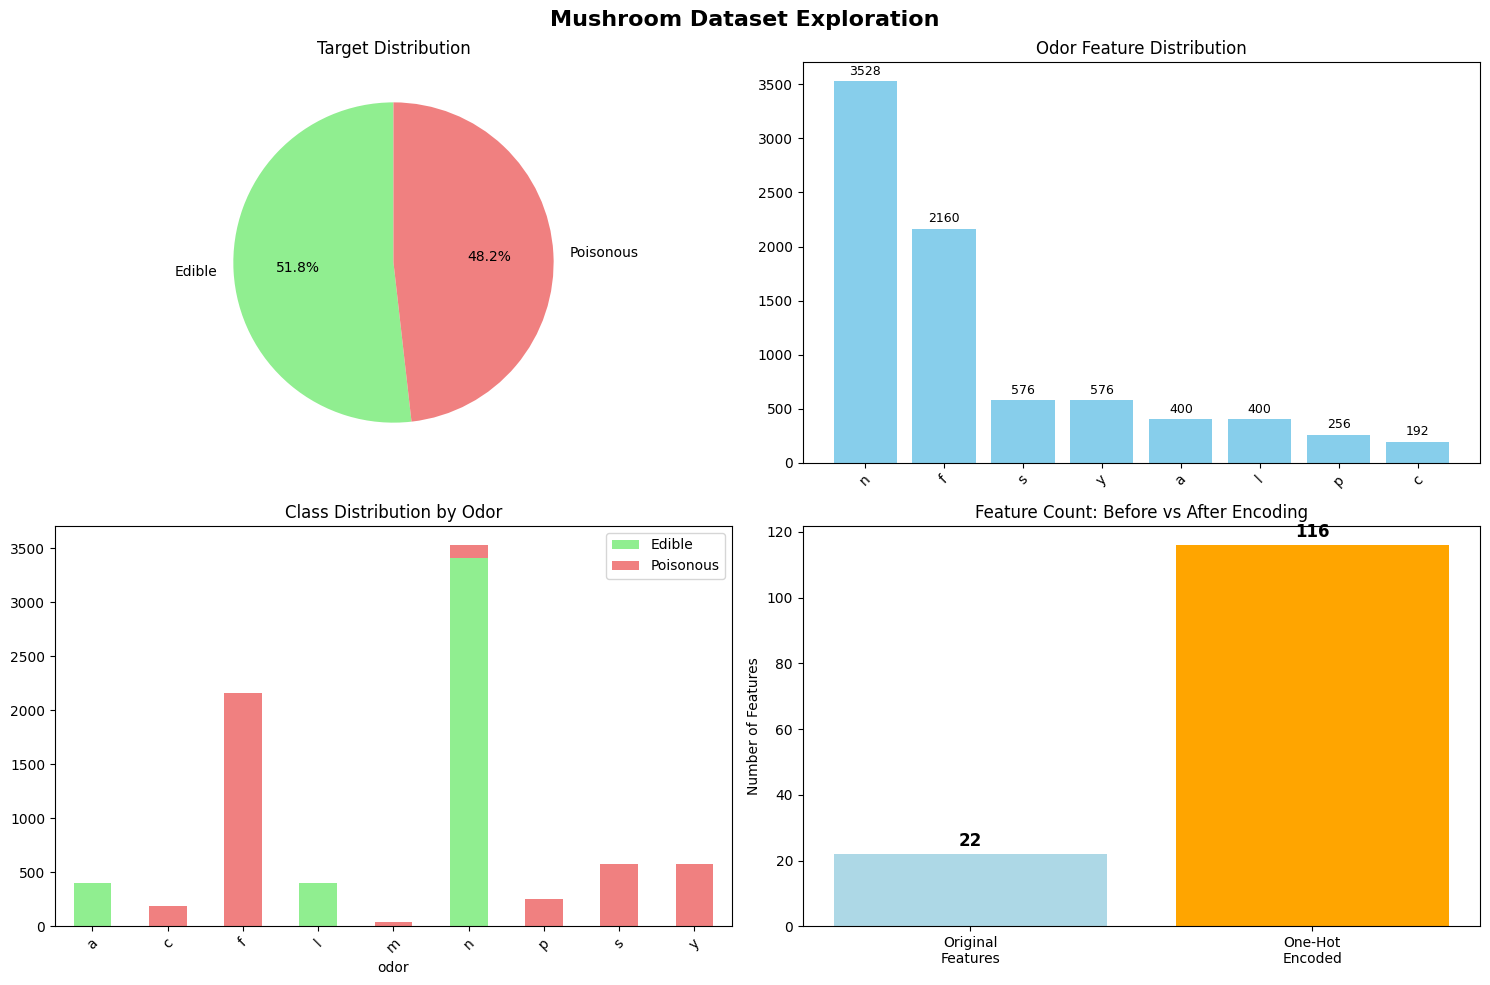


HYPERPARAMETER TUNING

Testing max_depth = 3
 Applying post-pruning...

...Starting Post-Pruning...
Initial validation accuracy: 0.9557
Found 5 internal nodes to consider for pruning

Pruning round 1:
No beneficial pruning found in this round

 Pruning completed!
Final validation accuracy: 0.9557
Total improvement: 0.0000
   Results:
    Train Accuracy: 0.9615
    Val Accuracy (before pruning):   0.9557
    Val Accuracy (after pruning):    0.9557
    Val F1-Score (after pruning):    0.9557
    Tree Depth (before/after):       3/3
    Pruning Improvement:              0.0000

Testing max_depth = 5
 Applying post-pruning...

...Starting Post-Pruning...
Initial validation accuracy: 0.9984
Found 10 internal nodes to consider for pruning

Pruning round 1:
No beneficial pruning found in this round

 Pruning completed!
Final validation accuracy: 0.9984
Total improvement: 0.0000
   Results:
    Train Accuracy: 0.9998
    Val Accuracy (before pruning):   0.9984
    Val Accuracy (after pruning)

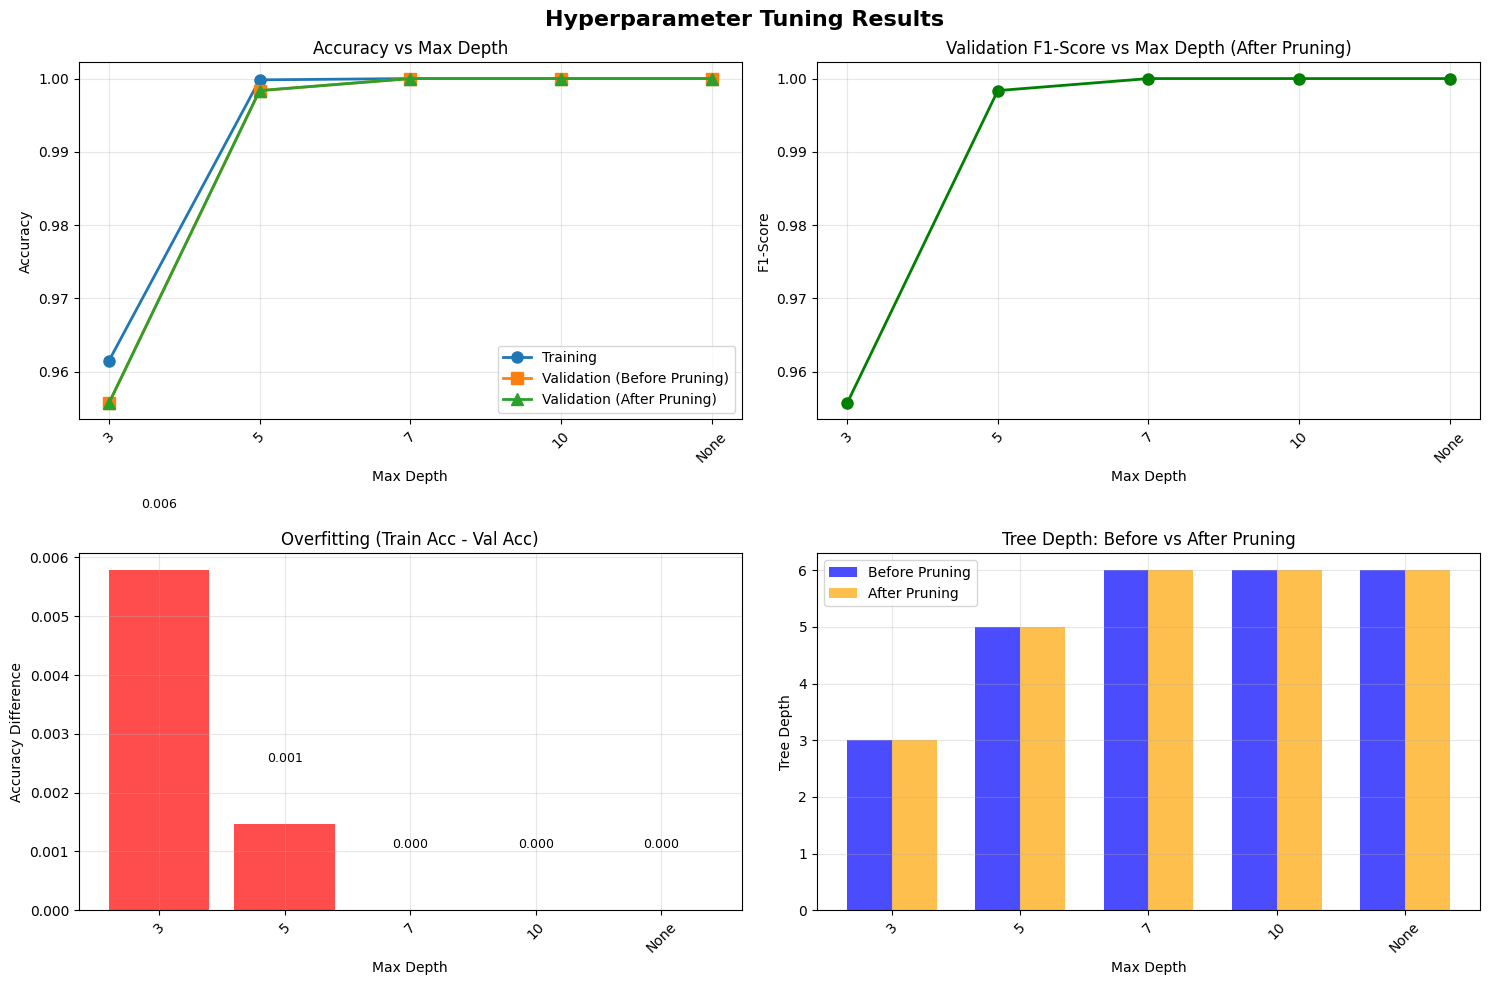


 Best max_depth: 7 (Pruned Val Accuracy: 1.0000)

DETAILED MODEL EVALUATION

Test Set Performance:
Overall Accuracy: 1.0000

Per-Class Metrics:
Edible (class e):
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
Poisonous (class p):
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


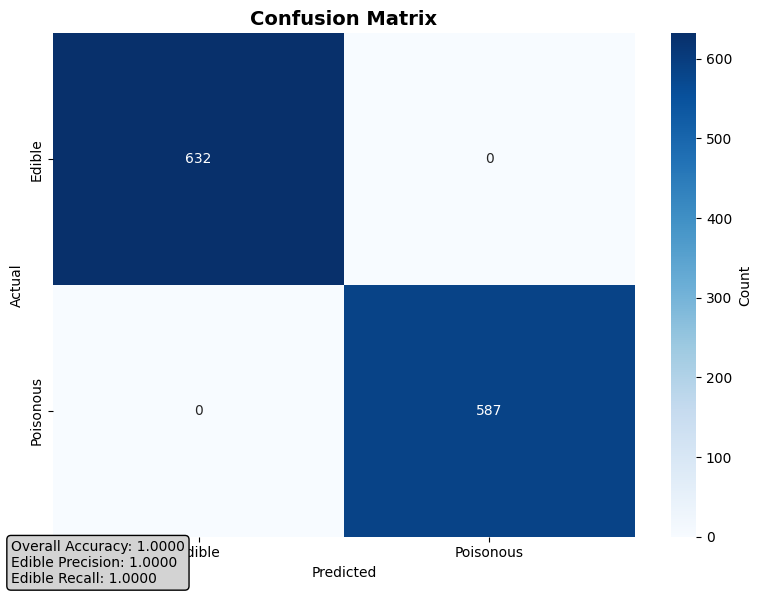


Feature Importance Analysis:
Features with non-zero importance: 9 out of 116

Top 10 Most Important Features:
Odor N                   : 0.5312
Bruises F                : 0.2137
Stalk-Root C             : 0.0640
Spore-Print-Color R      : 0.0523
Gill-Spacing C           : 0.0480
Stalk-Root R             : 0.0479
Stalk-Surface-Below-Ring Y: 0.0306
Gill-Size B              : 0.0070
Cap-Surface G            : 0.0053

Importance by Original Feature Category:
Odor                : 0.5312
Bruises             : 0.2137
Stalk Root          : 0.1119
Spore Print Color   : 0.0523
Gill Spacing        : 0.0480
Stalk Surface Below Ring: 0.0306
Gill Size           : 0.0070
Cap Surface         : 0.0053


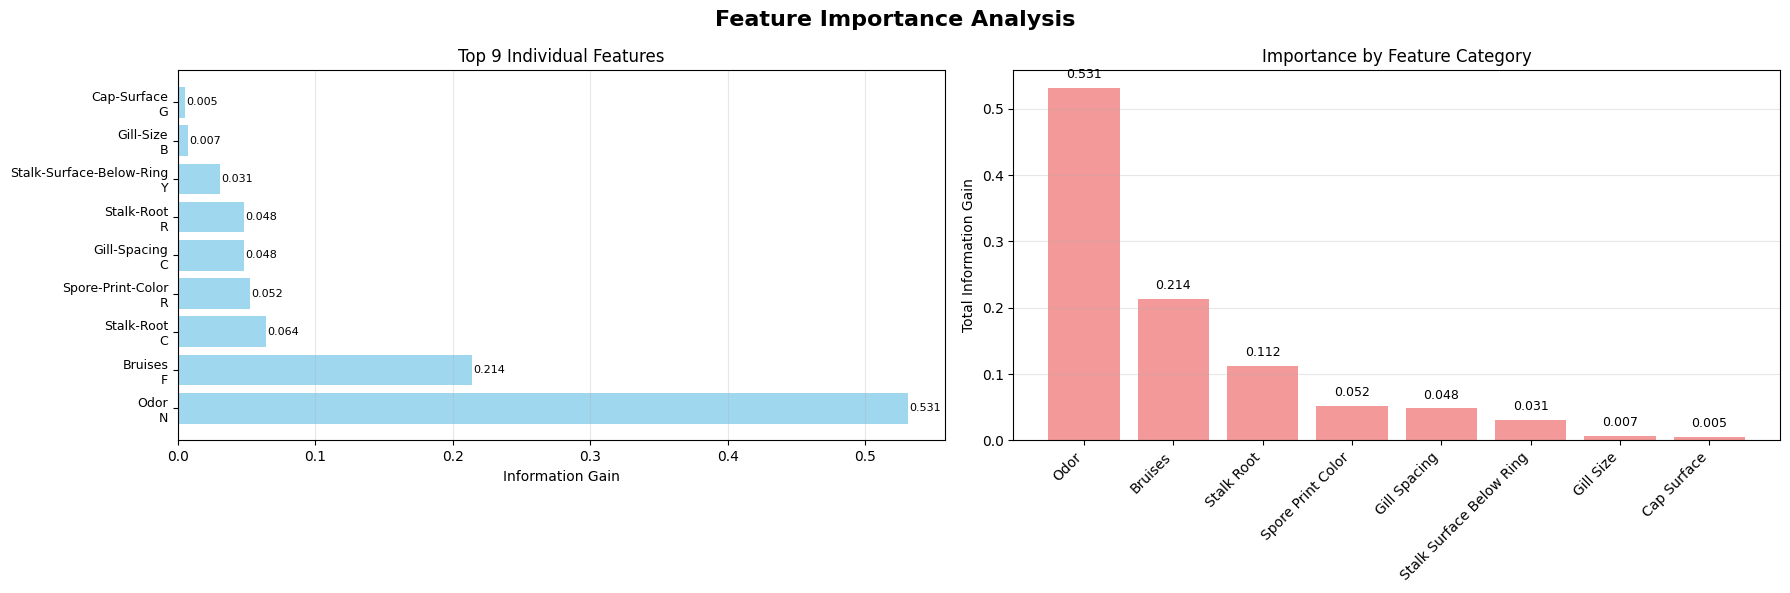


FINAL SUMMARY
 Best Model Configuration:
   Max Depth Setting: 7
   Actual Tree Depth: 6
   Validation Accuracy: 1.0000
   F1-Score: 1.0000
   Overfitting: 0.0000
   Pruning Benefit: 0.0000

 Final Test Set Performance:
   Test Accuracy: 1.0000
   Test F1-Score: 1.0000

TREE COMPLEXITY ANALYSIS

Tree Complexity Metrics:
 max_depth  actual_depth  node_count  leaf_count  val_accuracy  overfitting
       3.0             3          11           6      0.955701     0.005783
       5.0             5          21          11      0.998359     0.001465
       7.0             6          23          12      1.000000     0.000000
      10.0             6          23          12      1.000000     0.000000
       NaN             6          23          12      1.000000     0.000000


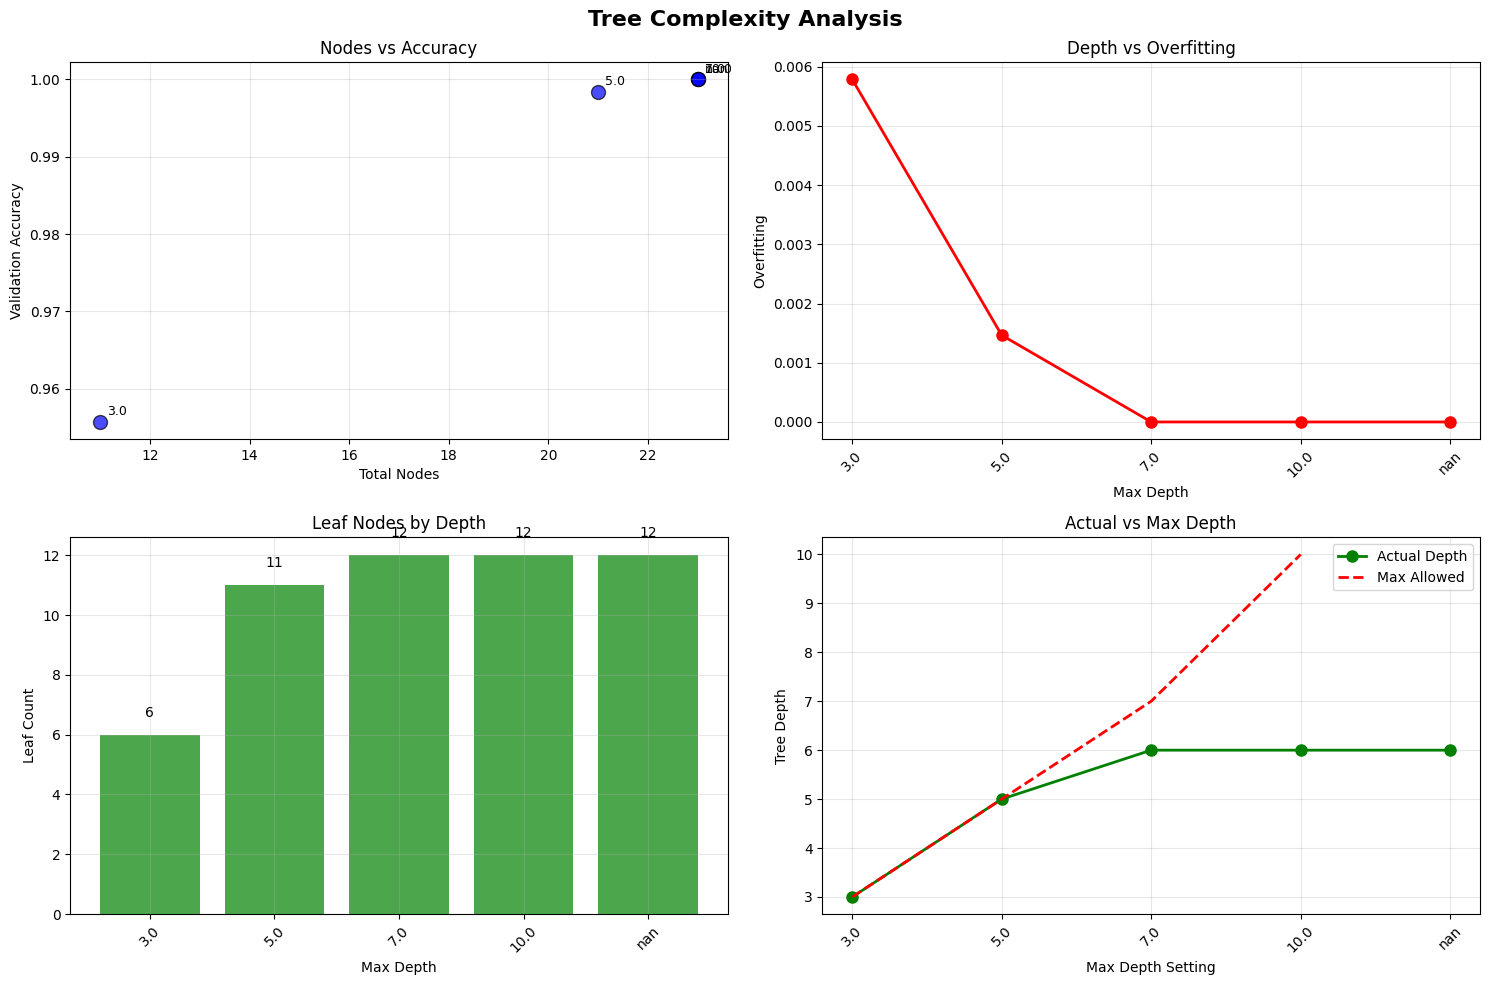


Graphical Tree Visualization (max depth: 7)


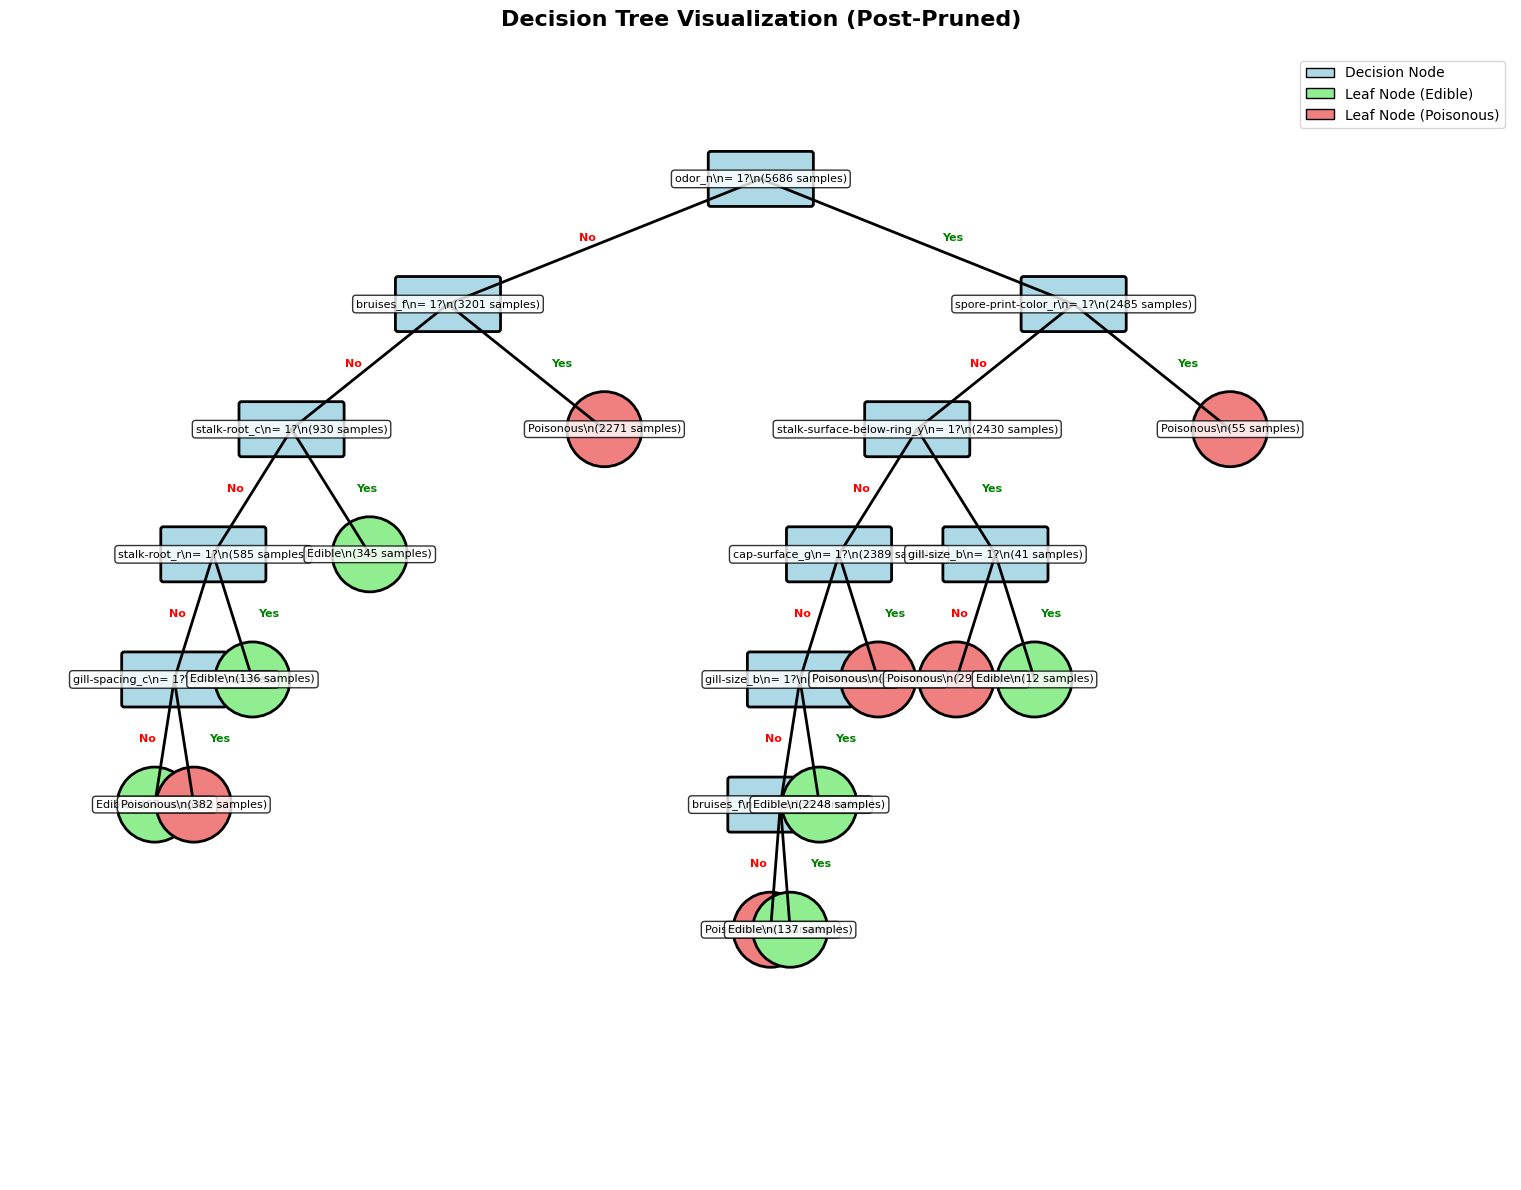

In [8]:
def main():
    np.random.seed(42)
    analyzer = MushroomAnalyzer()
    best_model = analyzer.run_complete_analysis()
    TreeAnalyzer.analyze_tree_complexity(analyzer.results)
    best_model.visualize_tree(max_depth=7)

if __name__ == "__main__":
    main()